In [149]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import cv2

from src.preprocessing import preprocess_image
from src.utils import show_image, show_images_grid


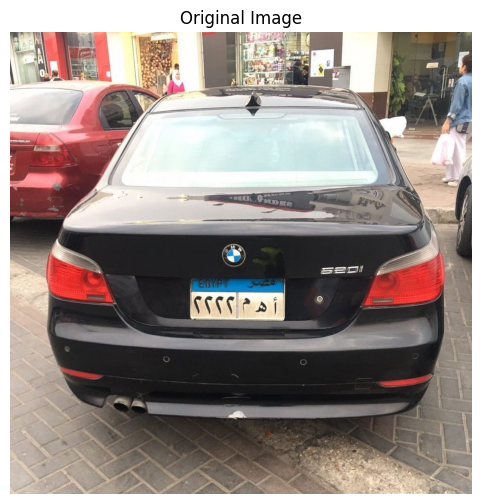

In [150]:
image_path = PROJECT_ROOT / "Data" / "test_images" / "0593.jpg"

image = cv2.imread(str(image_path))

if image is None:
    raise ValueError("Image not found. Check the image path.")

show_image("Original Image", image)

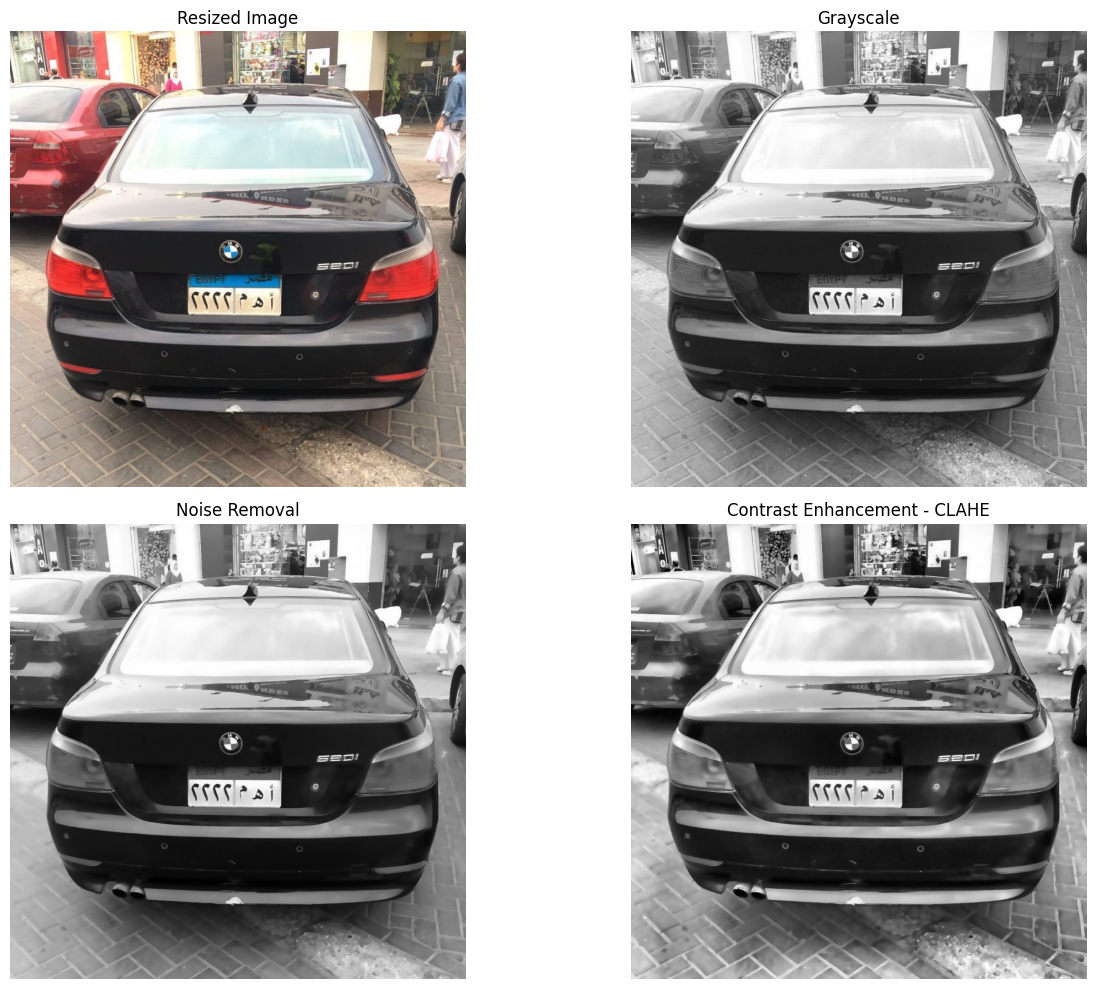

In [151]:
preprocessed = preprocess_image(image, width=900)

show_images_grid({
    "Resized Image": preprocessed["resized"],
    "Grayscale": preprocessed["gray"],
    "Noise Removal": preprocessed["denoised"],
    "Contrast Enhancement - CLAHE": preprocessed["enhanced"]
}, cols=2, figsize=(14, 10))

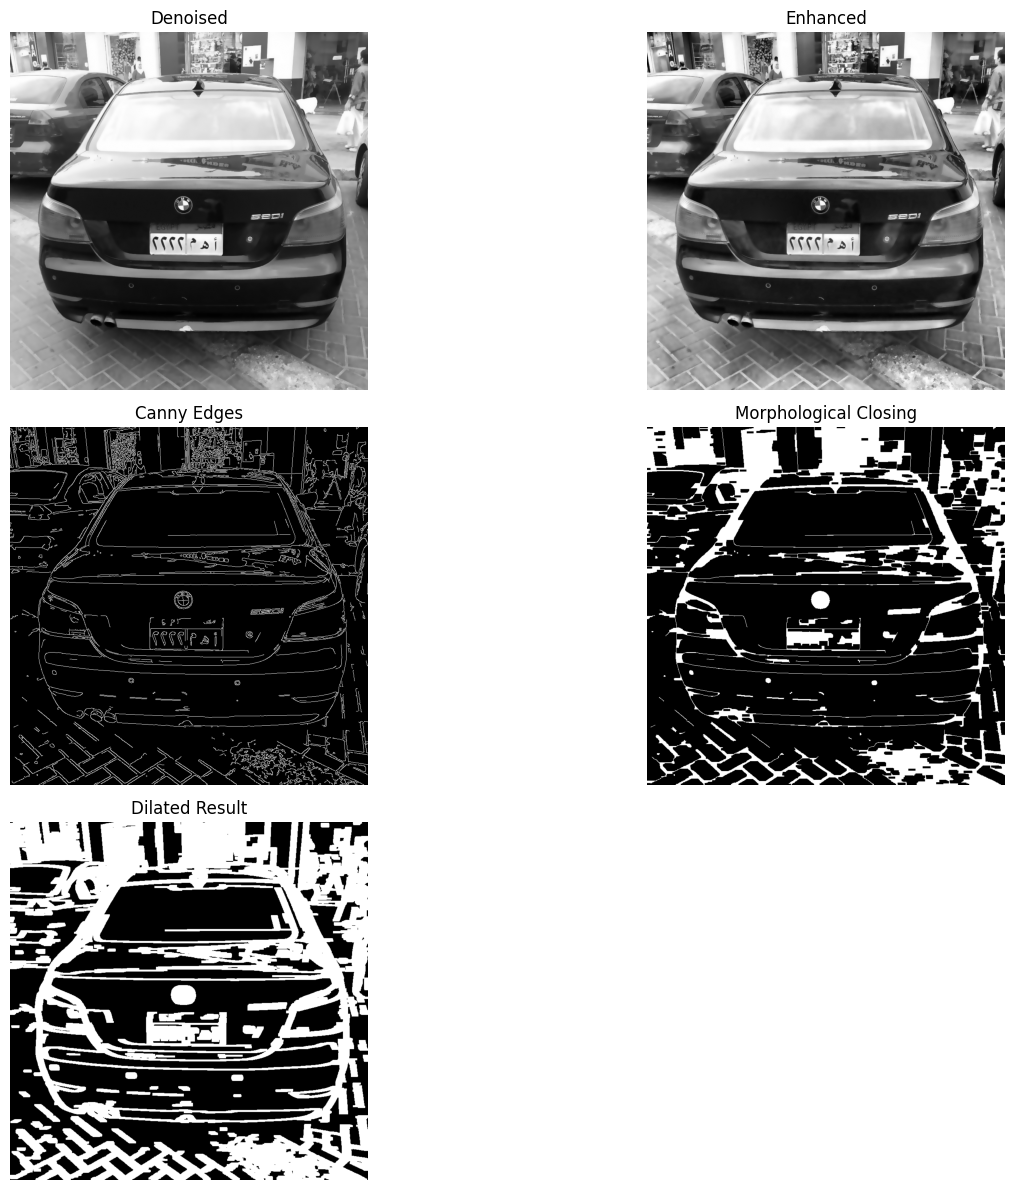

Lower Threshold: 84
Upper Threshold: 170


In [152]:
from src.detection import canny_pipeline
from src.utils import show_images_grid

gray = preprocessed["gray"]

canny_output = canny_pipeline(gray)

show_images_grid({
    "Denoised": canny_output["denoised"],
    "Enhanced": canny_output["enhanced"],
    "Canny Edges": canny_output["edges"],
    "Morphological Closing": canny_output["closed"],
    "Dilated Result": canny_output["dilated"]
}, cols=2, figsize=(14, 12))

print("Lower Threshold:", canny_output["lower_threshold"])
print("Upper Threshold:", canny_output["upper_threshold"])

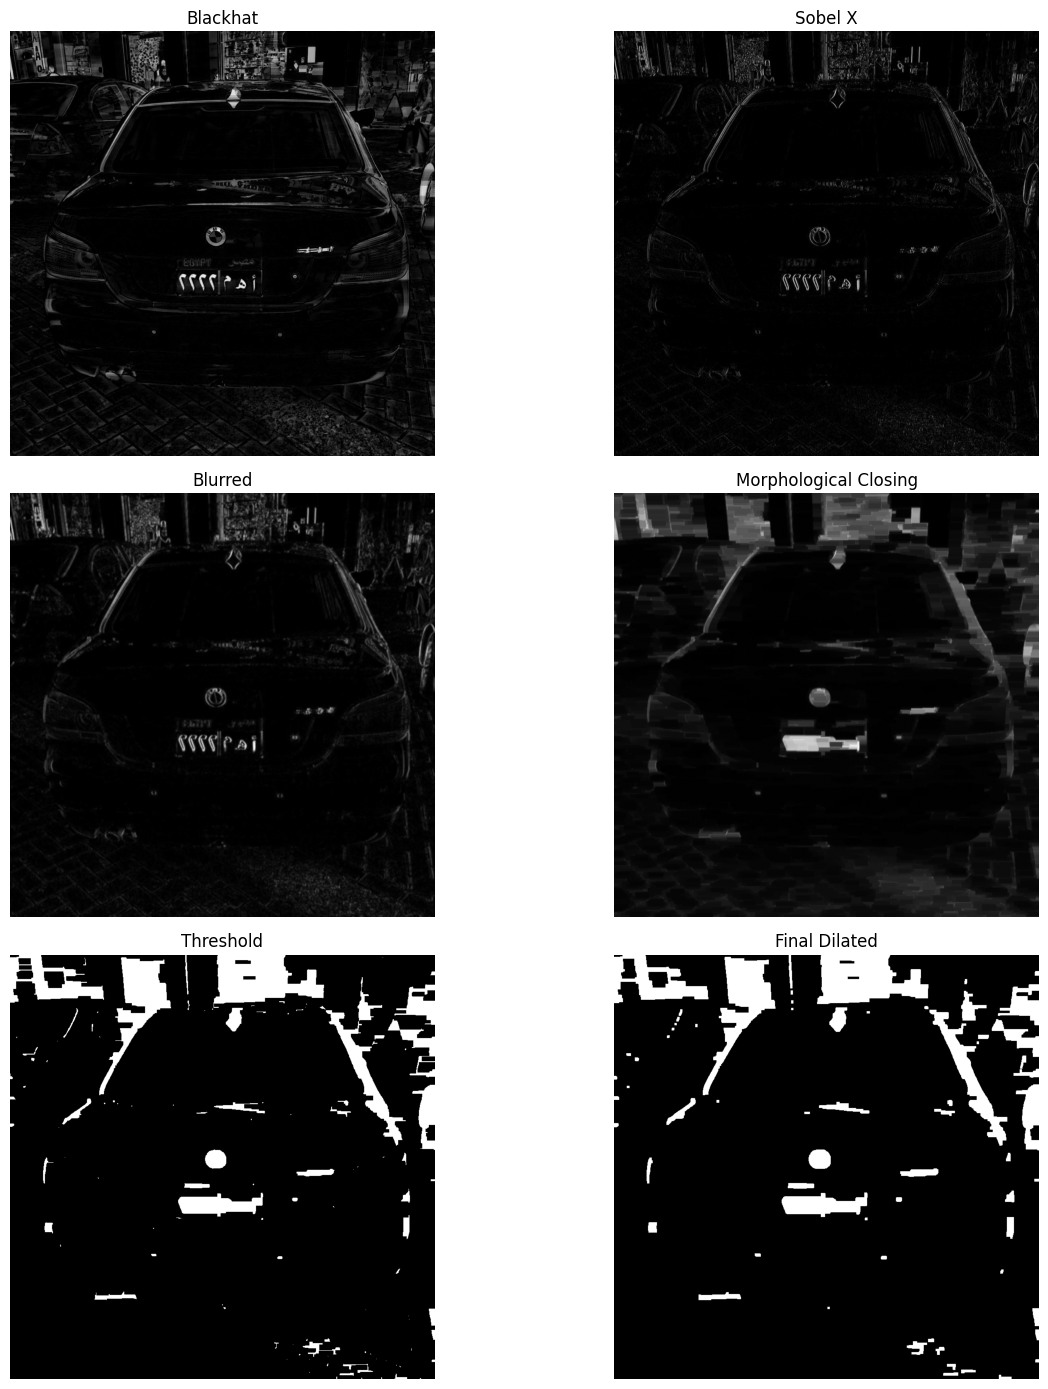

In [153]:
from src.detection import blackhat_pipeline

blackhat_output = blackhat_pipeline(gray)

show_images_grid({
    "Blackhat": blackhat_output["blackhat"],
    "Sobel X": blackhat_output["sobel_x"],
    "Blurred": blackhat_output["blurred"],
    "Morphological Closing": blackhat_output["closed"],
    "Threshold": blackhat_output["threshold"],
    "Final Dilated": blackhat_output["dilated"]
}, cols=2, figsize=(14, 14))